# Analise das metricas de prompt optimization do ncf

Este notebook percorre os diretorios `mmr_lambda_*` dentro de `out/prompt_optimization/Llama3.1-I/ncf`, procura os arquivos `optimization_process_metadata.json` e plota a evolucao das metricas por epoca para os experimentos do algoritmo `ncf`.

Ele tambem incorpora os resultados de teste salvos em `out/test_explainability`, mostrando:
- o teste `without_optimization`, exibido uma unica vez;
- e os testes `with_optimization` correspondentes a cada configuracao do `ncf`.

Observacoes:
- O eixo x representa a epoca.
- O eixo y representa o valor da metrica.
- Quando disponivel, o notebook plota as curvas de treino (`train_metric`) e validacao (`val_metric`).
- Para cada grafico, o notebook tambem exibe uma tabela pandas com os valores por epoca.
- Diretorios sem `optimization_process_metadata.json` sao reportados em tela.


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

SAVE_FIGURES = False

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_prompt_optimizer.py").exists() and (candidate / "out").exists():
            return candidate
    raise FileNotFoundError(
        "Nao foi possivel localizar a raiz de explainability-with-LLMs. "
        "Execute o notebook a partir do projeto ou de um subdiretorio dele."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ALGORITHM_NAME = "ncf"
DATA_DIR = PROJECT_ROOT / "out" / "prompt_optimization" / "Llama3.1-I" / ALGORITHM_NAME
ANALYSIS_DIR = DATA_DIR / "analysis"
FIGURES_DIR = ANALYSIS_DIR / "figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEST_ROOT = PROJECT_ROOT / "out" / "test_explainability"
DEFAULT_TEST_METADATA_PATH = TEST_ROOT / "without_optimization" / "Llama3.1-I" / ALGORITHM_NAME / "sep" / "responses_metadata.json"
TEST_WITH_OPT_DIR = TEST_ROOT / "with_optimization" / "Llama3.1-I" / ALGORITHM_NAME

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ALGORITHM_NAME: {ALGORITHM_NAME}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"DEFAULT_TEST_METADATA_PATH: {DEFAULT_TEST_METADATA_PATH}")
print(f"TEST_WITH_OPT_DIR: {TEST_WITH_OPT_DIR}")
if SAVE_FIGURES:
    print(f"FIGURES_DIR: {FIGURES_DIR}")


PROJECT_ROOT: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/09-new-optimization-version/prompt-optim-expl-rec/explainability-with-LLMs
ALGORITHM_NAME: ncf
DATA_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/09-new-optimization-version/prompt-optim-expl-rec/explainability-with-LLMs/out/prompt_optimization/Llama3.1-I/ncf
DEFAULT_TEST_METADATA_PATH: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/09-new-optimization-version/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/without_optimization/Llama3.1-I/ncf/sep/responses_metadata.json
TEST_WITH_OPT_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/09-new-optimization-version/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/with_optimization/Llama3.1-I/ncf


In [3]:
def lambda_to_float(lambda_name: str | None) -> float | None:
    if not lambda_name or not lambda_name.startswith("mmr_lambda_"):
        return None
    value = lambda_name.replace("mmr_lambda_", "")
    return float(value.replace("_", "."))


def find_named_parent(path: Path, prefix: str, default: str | None = None) -> str | None:
    for parent in path.parents:
        if parent.name.startswith(prefix):
            return parent.name
    return default


def build_lookup_key(
    repr_model: str,
    early_profile: str,
    mmr_lambda: str,
    mmr_pool: str,
    llm_method: str,
    metric: str,
) -> tuple[str, str, str, str, str, str]:
    return (repr_model, early_profile, mmr_lambda, mmr_pool, llm_method, metric)


def discover_metadata(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    lambda_dirs = sorted(
        (path for path in data_dir.rglob("mmr_lambda_*") if path.is_dir()),
        key=lambda path: lambda_to_float(path.name) if lambda_to_float(path.name) is not None else float("inf"),
    )

    rows = []
    missing = []

    for lambda_dir in lambda_dirs:
        metadata_files = sorted(lambda_dir.rglob("optimization_process_metadata.json"))
        if not metadata_files:
            missing.append(lambda_dir)
            continue

        for metadata_path in metadata_files:
            payload = json.loads(metadata_path.read_text())
            args = payload.get("args", {})
            rows.append(
                {
                    "optimization_mode": "with_optimization",
                    "algorithm": ALGORITHM_NAME,
                    "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                    "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                    "mmr_lambda": lambda_dir.name,
                    "lambda_value": lambda_to_float(lambda_dir.name),
                    "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "desconhecido"),
                    "llm_method": args.get("llm_method", "desconhecido"),
                    "metric": args.get("metric", "metric"),
                    "epochs": len(payload.get("epochs_history", [])),
                    "time_prompt_optimization": payload.get("time_prompt_optimization"),
                    "optimization_metadata_path": metadata_path,
                }
            )

    if rows:
        catalog = pd.DataFrame(rows).sort_values(
            ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
        ).reset_index(drop=True)
    else:
        catalog = pd.DataFrame(
            columns=[
                "optimization_mode",
                "algorithm",
                "repr_model",
                "early_profile",
                "mmr_lambda",
                "lambda_value",
                "mmr_pool",
                "llm_method",
                "metric",
                "epochs",
                "time_prompt_optimization",
                "optimization_metadata_path",
            ]
        )

    catalog["metadata_path"] = catalog["optimization_metadata_path"]
    return catalog, missing


def load_test_metadata(metadata_path: Path) -> dict:
    return json.loads(metadata_path.read_text())


def discover_default_test_result(metadata_path: Path) -> pd.DataFrame:
    if not metadata_path.exists():
        return pd.DataFrame()

    payload = load_test_metadata(metadata_path)
    args = payload.get("args", {})
    return pd.DataFrame(
        [
            {
                "optimization_mode": "without_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": pd.NA,
                "early_profile": pd.NA,
                "mmr_lambda": pd.NA,
                "lambda_value": pd.NA,
                "mmr_pool": pd.NA,
                "llm_method": args.get("llm_method", "desconhecido"),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "time_prompt_optimization": 0.0,
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "epochs": pd.NA,
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": pd.NA,
                "optimization_metadata_path": pd.NA,
                "responses_metadata_path": metadata_path,
            }
        ]
    )


def discover_with_optimization_test_results(test_dir: Path) -> pd.DataFrame:
    rows = []

    for metadata_path in sorted(test_dir.rglob("responses_metadata.json")):
        payload = load_test_metadata(metadata_path)
        args = payload.get("args", {})
        mmr_lambda = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
        rows.append(
            {
                "optimization_mode": "with_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                "mmr_lambda": mmr_lambda,
                "lambda_value": lambda_to_float(mmr_lambda),
                "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
                "llm_method": args.get("llm_method", payload.get("best_prompt_model", "desconhecido")),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": payload.get("best_prompt_path"),
                "responses_metadata_path": metadata_path,
            }
        )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(
        ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
    ).reset_index(drop=True)


def build_final_overview_table(default_test_result: pd.DataFrame, optimization_catalog: pd.DataFrame, with_opt_test_catalog: pd.DataFrame) -> pd.DataFrame:
    preferred_columns = [
        "optimization_mode",
        "algorithm",
        "repr_model",
        "early_profile",
        "mmr_lambda",
        "lambda_value",
        "mmr_pool",
        "llm_method",
        "metric",
        "metric_name",
        "epochs",
        "test_metric_value",
        "n_users",
        "time_to_explain",
        "time_prompt_optimization",
        "prompt_source",
        "best_prompt_path",
        "optimization_metadata_path",
        "responses_metadata_path",
    ]

    rows = []

    if not default_test_result.empty:
        rows.extend(default_test_result.reindex(columns=preferred_columns).to_dict("records"))

    if not optimization_catalog.empty:
        merged_catalog = optimization_catalog.copy()
        if not with_opt_test_catalog.empty:
            merged_catalog = merged_catalog.merge(
                with_opt_test_catalog[
                    [
                        "repr_model",
                        "early_profile",
                        "mmr_lambda",
                        "mmr_pool",
                        "llm_method",
                        "metric",
                        "metric_name",
                        "test_metric_value",
                        "n_users",
                        "time_to_explain",
                        "prompt_source",
                        "system_prompt",
                        "best_prompt_path",
                        "responses_metadata_path",
                    ]
                ],
                on=["repr_model", "early_profile", "mmr_lambda", "mmr_pool", "llm_method", "metric"],
                how="left",
            )
        else:
            merged_catalog["metric_name"] = pd.NA
            merged_catalog["test_metric_value"] = pd.NA
            merged_catalog["n_users"] = pd.NA
            merged_catalog["time_to_explain"] = pd.NA
            merged_catalog["prompt_source"] = pd.NA
            merged_catalog["system_prompt"] = pd.NA
            merged_catalog["best_prompt_path"] = pd.NA
            merged_catalog["responses_metadata_path"] = pd.NA

        rows.extend(merged_catalog.reindex(columns=preferred_columns).to_dict("records"))

    if not rows:
        return pd.DataFrame(columns=preferred_columns)

    overview = pd.DataFrame(rows, columns=preferred_columns)
    overview["optimization_order"] = overview["optimization_mode"].map(
        {"without_optimization": 0, "with_optimization": 1}
    )
    overview = overview.sort_values(
        by=["optimization_order", "repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"],
        na_position="last",
    ).reset_index(drop=True)

    return overview[preferred_columns]


catalog, missing_lambda_dirs = discover_metadata(DATA_DIR)
default_test_result = discover_default_test_result(DEFAULT_TEST_METADATA_PATH)
with_opt_test_catalog = discover_with_optimization_test_results(TEST_WITH_OPT_DIR)
final_overview_table = build_final_overview_table(default_test_result, catalog, with_opt_test_catalog)

DEFAULT_TEST_RESULT = default_test_result.iloc[0].to_dict() if not default_test_result.empty else None
TEST_RESULTS_BY_KEY = {
    build_lookup_key(
        row["repr_model"],
        row["early_profile"],
        row["mmr_lambda"],
        row["mmr_pool"],
        row["llm_method"],
        row["metric"],
    ): row.to_dict()
    for _, row in with_opt_test_catalog.iterrows()
}

print(f"Linhas na tabela final de {ALGORITHM_NAME}: {len(final_overview_table)}")
if not final_overview_table.empty:
    display(final_overview_table)
else:
    warnings.warn(f"Nao foi possivel montar a tabela final de {ALGORITHM_NAME}.")

if missing_lambda_dirs:
    warnings.warn(
        "Diretorios sem optimization_process_metadata.json: "
        + ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_lambda_dirs)
    )




Linhas na tabela final de ncf: 7


,optimization_mode,algorithm,repr_model,early_profile,mmr_lambda,lambda_value,mmr_pool,llm_method,metric,metric_name,epochs,test_metric_value,n_users,time_to_explain,time_prompt_optimization,prompt_source,best_prompt_path,optimization_metadata_path,responses_metadata_path
0,without_optimization,ncf,None,None,None,NaN,None,Llama3.1-I,sep,SEP,NaN,0.627519,122,215.434206,0.000000,default,None,None,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
1,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.640214,122,215.448118,9747.848733,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
2,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.643438,122,213.730486,9679.462396,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
3,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.638208,122,215.119633,9748.439306,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
4,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.635030,122,215.885780,9674.257750,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
5,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.625379,122,211.512828,9684.256407,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
6,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.643438,122,214.882680,9677.675944,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...


In [4]:
def load_history(metadata_path: Path) -> tuple[dict, pd.DataFrame, str, str, str]:
    payload = json.loads(metadata_path.read_text())
    history = pd.DataFrame(payload.get("epochs_history", []))
    if history.empty:
        raise ValueError(f"Nenhum dado de epoca encontrado em {metadata_path}")

    history = history.sort_values("epoch").reset_index(drop=True)
    metric_name = payload.get("args", {}).get("metric", "metric")
    lambda_name = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
    pool_name = find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido")
    return payload, history, metric_name, lambda_name, pool_name


def build_history_table(history: pd.DataFrame, metric_name: str, lambda_name: str, pool_name: str) -> pd.DataFrame:
    table = history.copy()
    table.insert(0, "metric", metric_name)
    table.insert(0, "mmr_pool", pool_name)
    table.insert(0, "mmr_lambda", lambda_name)

    preferred_columns = ["mmr_lambda", "mmr_pool", "metric", "epoch", "train_metric", "val_metric"]
    ordered_columns = [column for column in preferred_columns if column in table.columns]
    ordered_columns.extend(column for column in table.columns if column not in ordered_columns)
    return table[ordered_columns]


def make_output_stem(metadata_path: Path) -> str:
    relative = metadata_path.relative_to(DATA_DIR)
    cleaned_parts = [part.replace('.', '_') for part in relative.parts[:-1]]
    return "__".join(cleaned_parts)


def format_metric(value: float | None) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.4f}"


def format_delta(value: float | None) -> str:
    if value is None or pd.isna(value):
        return "sem anterior"
    return f"{float(value):+.4f}"


def metric_delta(current: float | None, previous: float | None) -> float | None:
    if current is None or previous is None or pd.isna(current) or pd.isna(previous):
        return None
    return float(current) - float(previous)


def format_refs(refs: list[dict] | None) -> str:
    if not refs:
        return "sem refs MMR"

    chunks = []
    for ref in refs:
        epoch = ref.get("epoch", "?")
        score = ref.get("train_score")
        if score is None:
            chunks.append(f"epoca {epoch}")
        else:
            chunks.append(f"epoca {epoch} ({float(score):.4f})")
    return ", ".join(chunks)


def build_prompt_summary_table(history_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    previous_prompt = None
    previous_train = None
    previous_val = None

    for _, row in history_table.iterrows():
        current_prompt = row.get("prompt_this_epoch") or ""
        current_train = row.get("train_metric")
        current_val = row.get("val_metric")
        prompt_changed = False if previous_prompt is None else current_prompt != previous_prompt

        rows.append(
            {
                "epoch": int(row["epoch"]),
                "train_metric": float(current_train) if pd.notna(current_train) else None,
                "train_delta": metric_delta(current_train, previous_train),
                "val_metric": float(current_val) if pd.notna(current_val) else None,
                "val_delta": metric_delta(current_val, previous_val),
                "generated_new_prompt": bool(row.get("generated_new_prompt")),
                "prompt_changed": prompt_changed,
                "prompt_chars": len(current_prompt),
                "mmr_refs": format_refs(row.get("mmr_selected_reference_epochs")),
            }
        )

        previous_prompt = current_prompt
        previous_train = current_train if pd.notna(current_train) else None
        previous_val = current_val if pd.notna(current_val) else None

    return pd.DataFrame(rows)


def build_run_highlights_markdown(payload: dict, history_table: pd.DataFrame) -> str:
    best_train = payload.get("best_on_train", {})
    best_val = payload.get("best_on_validation", {})
    final_epoch = int(history_table.iloc[-1]["epoch"])

    return "\n".join(
        [
            "## Destaques da rodada do ncf",
            f"- Melhor treino: epoca {best_train.get('best_train_epoch', 'n/a')} com valor {format_metric(best_train.get('best_train_metric'))}",
            f"- Melhor validacao: epoca {best_val.get('best_val_epoch', 'n/a')} com valor {format_metric(best_val.get('best_val_metric'))}",
            f"- Ultimo prompt avaliado: epoca {final_epoch}",
        ]
    )


def build_summary_legend_markdown() -> str:
    return "\n".join(
        [
            "## Como ler a tabela do ncf",
            "- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.",
            "- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.",
            "- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.",
            "- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.",
            "- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.",
        ]
    )


def build_default_test_markdown(default_test: dict | None) -> str:
    if not default_test:
        return "\n".join([
            "## Teste without_optimization",
            "- Nenhum resultado de teste default foi encontrado.",
        ])

    metadata_path = Path(default_test["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Teste without_optimization",
            f"- Metrica de teste ({default_test['metric_name']}): {format_metric(default_test['test_metric_value'])}",
            f"- Prompt source: {default_test['prompt_source']}",
            f"- Usuarios avaliados: {int(default_test['n_users'])}",
            f"- Tempo para explicar: {float(default_test['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def find_test_result_for_metadata(metadata_path: Path, payload: dict) -> dict | None:
    key = build_lookup_key(
        find_named_parent(metadata_path, "repr_", "desconhecido"),
        find_named_parent(metadata_path, "early_", "desconhecido"),
        find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
        find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        payload.get("args", {}).get("llm_method", "desconhecido"),
        payload.get("args", {}).get("metric", "metric"),
    )
    return TEST_RESULTS_BY_KEY.get(key)


def build_test_result_markdown(test_result: dict | None, default_test: dict | None) -> str:
    if not test_result:
        return "\n".join([
            "## Resultado no teste do ncf",
            "- Nenhum resultado de teste correspondente foi encontrado para esta configuracao.",
        ])

    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None and test_result.get("test_metric_value") is not None:
        delta_vs_default = float(test_result["test_metric_value"]) - float(default_test["test_metric_value"])

    metadata_path = Path(test_result["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Resultado no teste do ncf",
            f"- Metrica de teste ({test_result['metric_name']}): {format_metric(test_result['test_metric_value'])}",
            f"- Delta vs without_optimization: {format_delta(delta_vs_default)}",
            f"- Prompt source: {test_result['prompt_source']}",
            f"- Usuarios avaliados: {int(test_result['n_users'])}",
            f"- Tempo para explicar: {float(test_result['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def get_metric_at_epoch(history_table: pd.DataFrame, epoch: int, column: str) -> float | None:
    rows = history_table.loc[history_table["epoch"] == epoch, column]
    if rows.empty:
        return None
    value = rows.iloc[0]
    if pd.isna(value):
        return None
    return float(value)


def build_final_report_markdown(
    metadata_path: Path,
    payload: dict,
    history_table: pd.DataFrame,
    test_result: dict | None,
    default_test: dict | None,
) -> str:
    best_train = payload.get("best_on_train", {})
    best_epoch = int(best_train.get("best_train_epoch", 0) or 0)
    best_prompt = best_train.get("best_train_prompt") or payload.get("baseline_prompt") or ""
    base_prompt = payload.get("baseline_prompt") or history_table.iloc[0].get("prompt_this_epoch") or ""

    base_train = get_metric_at_epoch(history_table, 0, "train_metric")
    best_train_metric = best_train.get("best_train_metric")
    train_gain_vs_base = metric_delta(best_train_metric, base_train)

    base_val = get_metric_at_epoch(history_table, 0, "val_metric")
    best_val_at_best_epoch = get_metric_at_epoch(history_table, best_epoch, "val_metric")
    val_gain_vs_base = metric_delta(best_val_at_best_epoch, base_val)

    test_gain_vs_default = None
    if default_test and test_result:
        test_gain_vs_default = metric_delta(test_result.get("test_metric_value"), default_test.get("test_metric_value"))

    config_label = " | ".join(
        [
            find_named_parent(metadata_path, "repr_", "desconhecido"),
            find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
            find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        ]
    )

    lines = [
        f"### {config_label}",
        f"- Melhor epoca: {best_epoch}",
        f"- Ganho da melhor epoca vs base no treino: {format_delta(train_gain_vs_base)} ({format_metric(base_train)} -> {format_metric(best_train_metric)})",
        f"- Ganho da melhor epoca vs base na validacao: {format_delta(val_gain_vs_base)} ({format_metric(base_val)} -> {format_metric(best_val_at_best_epoch)})",
        f"- Teste sem otimizacao vs com melhor prompt: {format_metric(default_test.get('test_metric_value') if default_test else None)} -> {format_metric(test_result.get('test_metric_value') if test_result else None)} ({format_delta(test_gain_vs_default)})",
        "- Prompt base (epoca 0):",
        "```text",
        base_prompt,
        "```",
        "- Melhor prompt:",
        "```text",
        best_prompt,
        "```",
    ]
    return "\n".join(lines)


def build_best_test_summary_markdown(default_test: dict | None, with_opt_test_catalog: pd.DataFrame) -> str:
    lines = ["### Comparacao final de teste"]

    if default_test:
        lines.extend(
            [
                f"- Sem otimizacao: {format_metric(default_test.get('test_metric_value'))} em {default_test.get('metric_name', 'METRIC')}",
                f"- Tempo sem otimizacao: {float(default_test.get('time_to_explain')):.2f}s",
                "- Prompt sem otimizacao:",
                "```text",
                default_test.get("system_prompt") or "prompt nao encontrado",
                "```",
            ]
        )
    else:
        lines.append("- Sem otimizacao: resultado nao encontrado")

    if with_opt_test_catalog.empty:
        lines.append("- Melhor resultado com otimizacao: nao encontrado")
        return "\n".join(lines)

    best_row = with_opt_test_catalog.sort_values("test_metric_value", ascending=False).iloc[0]
    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None:
        delta_vs_default = metric_delta(best_row.get("test_metric_value"), default_test.get("test_metric_value"))

    lines.extend(
        [
            f"- Melhor resultado com otimizacao: {format_metric(best_row.get('test_metric_value'))} em {best_row.get('metric_name', 'METRIC')}",
            f"- Melhor configuracao no teste: {best_row.get('mmr_lambda')} | {best_row.get('repr_model')}",
            f"- Tempo da melhor configuracao: {float(best_row.get('time_to_explain')):.2f}s",
            f"- Ganho vs sem otimizacao: {format_delta(delta_vs_default)}",
            "- Prompt da melhor configuracao no teste:",
            "```text",
            best_row.get("system_prompt") or "prompt nao encontrado",
            "```",
        ]
    )
    return "\n".join(lines)


def build_prompt_epoch_markdown(history_row: pd.Series, summary_row: pd.Series) -> str:
    epoch = int(history_row["epoch"])
    prompt = history_row.get("prompt_this_epoch") or ""

    if epoch == 0:
        prompt_status = "baseline"
    elif bool(summary_row["prompt_changed"]):
        prompt_status = "novo prompt"
    else:
        prompt_status = "prompt reaproveitado"

    return "\n".join(
        [
            f"### Epoca {epoch}",
            f"- Status do prompt: {prompt_status}",
            f"- Train: {format_metric(summary_row['train_metric'])} ({format_delta(summary_row['train_delta'])})",
            f"- Validacao: {format_metric(summary_row['val_metric'])} ({format_delta(summary_row['val_delta'])})",
            f"- Refs MMR: {summary_row['mmr_refs']}",
            f"- Tamanho do prompt: {int(summary_row['prompt_chars'])} caracteres",
            "",
            "Prompt completo:",
            "```text",
            prompt,
            "```",
        ]
    )


def plot_history(metadata_path: Path, save_figures: bool = False) -> None:
    payload, history, metric_name, lambda_name, pool_name = load_history(metadata_path)
    history_table = build_history_table(history, metric_name, lambda_name, pool_name)
    summary_table = build_prompt_summary_table(history_table)
    test_result = find_test_result_for_metadata(metadata_path, payload)

    display(Markdown(build_run_highlights_markdown(payload, history_table)))
    display(Markdown(build_test_result_markdown(test_result, DEFAULT_TEST_RESULT)))

    summary_display = summary_table.copy()
    summary_display["generated_new_prompt"] = summary_display["generated_new_prompt"].map(lambda value: "sim" if value else "nao")
    summary_display["prompt_changed"] = summary_display["prompt_changed"].map(lambda value: "sim" if value else "nao")
    display(Markdown(build_summary_legend_markdown()))
    display(summary_display)

    fig, ax = plt.subplots(figsize=(10, 5))
    plotted_columns = []

    if "train_metric" in history.columns and history["train_metric"].notna().any():
        ax.plot(history["epoch"], history["train_metric"], marker="o", linewidth=2, label="Treino")
        plotted_columns.append("train_metric")

    if "val_metric" in history.columns and history["val_metric"].notna().any():
        ax.plot(history["epoch"], history["val_metric"], marker="s", linewidth=2, label="Validacao")
        plotted_columns.append("val_metric")

    if not plotted_columns:
        plt.close(fig)
        raise ValueError(f"Nenhuma coluna de metrica encontrada em {metadata_path}")

    repr_name = find_named_parent(metadata_path, "repr_", "repr_desconhecido")
    ax.set_title(f"{lambda_name} | {metric_name.upper()} | {repr_name}")
    ax.set_xlabel("Epoca")
    ax.set_ylabel(f"Valor da metrica ({metric_name})")
    ax.set_xticks(history["epoch"].tolist())
    ax.legend()

    y_values = pd.concat([history[column] for column in plotted_columns], axis=0).dropna()
    if not y_values.empty:
        y_min = max(0.0, float(y_values.min()) - 0.02)
        y_max = min(1.0, float(y_values.max()) + 0.02)
        if y_min < y_max:
            ax.set_ylim(y_min, y_max)

    fig.tight_layout()

    if save_figures:
        output_name = f"{make_output_stem(metadata_path)}.png"
        fig.savefig(FIGURES_DIR / output_name, dpi=150, bbox_inches="tight")

    plt.show()

    display(Markdown("## Prompts por epoca no ncf"))
    for row_index, history_row in history_table.iterrows():
        summary_row = summary_table.iloc[row_index]
        display(Markdown(build_prompt_epoch_markdown(history_row, summary_row)))

## Teste without_optimization
- Metrica de teste (SEP): 0.6275
- Prompt source: default
- Usuarios avaliados: 122
- Tempo para explicar: 215.43s
- Arquivo de origem: `out/test_explainability/without_optimization/Llama3.1-I/ncf/sep/responses_metadata.json`

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 8 com valor 0.6773
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6402
- Delta vs without_optimization: +0.0127
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 215.45s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.661578,0.010743,0.655920,0.020208,sim,sim,293,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 3 (0..."
5,5,0.640863,-0.020715,0.615822,-0.040098,sim,sim,622,"epoca 1 (0.6655), epoca 4 (0.6616), epoca 0 (0..."
6,6,0.673581,0.032718,0.665361,0.049539,sim,sim,297,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 5 (0..."
7,7,0.669349,-0.004232,0.650061,-0.015300,sim,sim,387,"epoca 6 (0.6736), epoca 1 (0.6655), epoca 0 (0..."
8,8,0.677343,0.007994,0.661208,0.011148,sim,sim,391,"epoca 6 (0.6736), epoca 1 (0.6655), epoca 0 (0..."
9,9,0.671400,-0.005943,0.673429,0.012220,sim,sim,449,"epoca 8 (0.6773), epoca 1 (0.6655), epoca 0 (0..."


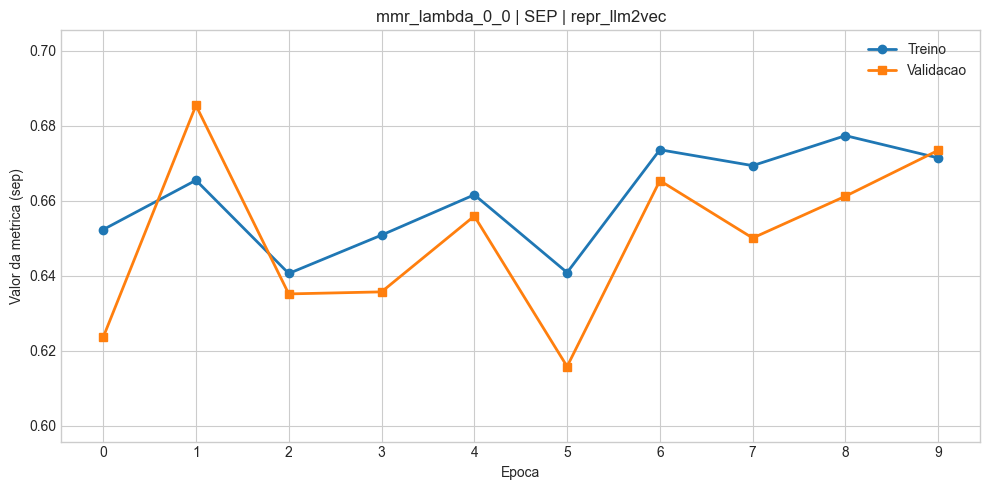

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 4 com valor 0.6737
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6434
- Delta vs without_optimization: +0.0159
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 213.73s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.673748,0.022914,0.665467,0.029755,sim,sim,261,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
5,5,0.658410,-0.015338,0.649642,-0.015825,sim,sim,262,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 3 (0..."
6,6,0.662414,0.004004,0.644098,-0.005545,sim,sim,303,"epoca 4 (0.6737), epoca 0 (0.6523), epoca 3 (0..."
7,7,0.656491,-0.005924,0.640000,-0.004098,sim,sim,305,"epoca 4 (0.6737), epoca 0 (0.6523), epoca 3 (0..."
8,8,0.650631,-0.005859,0.649249,0.009249,sim,sim,308,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 7 (0..."
9,9,0.635708,-0.014923,0.621236,-0.028013,sim,sim,431,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 7 (0..."


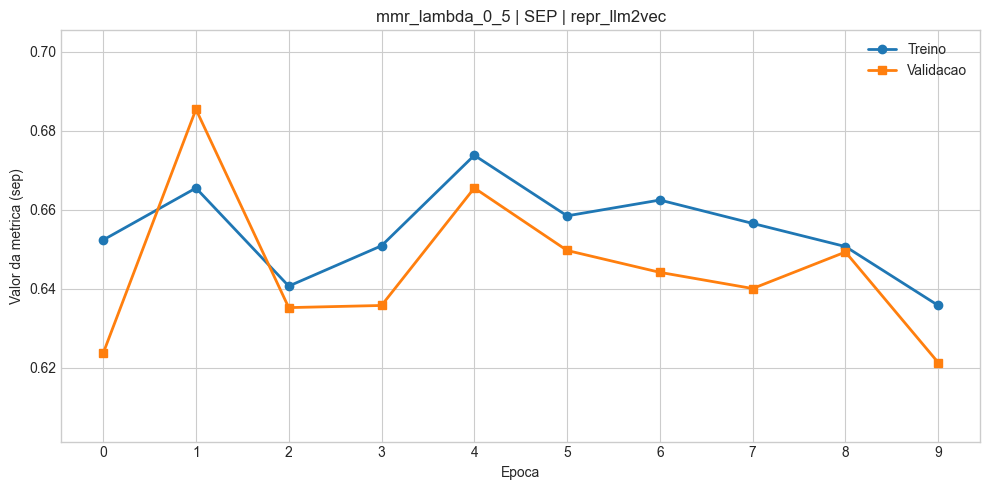

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 8 com valor 0.6813
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6382
- Delta vs without_optimization: +0.0107
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 215.12s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.671376,0.020541,0.675211,0.039499,sim,sim,452,"epoca 1 (0.6655), epoca 3 (0.6508), epoca 2 (0..."
5,5,0.664996,-0.006380,0.642552,-0.032659,sim,sim,415,"epoca 4 (0.6714), epoca 3 (0.6508), epoca 2 (0..."
6,6,0.661586,-0.003411,0.676992,0.034441,sim,sim,446,"epoca 4 (0.6714), epoca 5 (0.6650), epoca 2 (0..."
7,7,0.663297,0.001712,0.672716,-0.004276,sim,sim,540,"epoca 4 (0.6714), epoca 5 (0.6650), epoca 6 (0..."
8,8,0.681267,0.017969,0.674642,0.001926,sim,sim,388,"epoca 4 (0.6714), epoca 5 (0.6650), epoca 6 (0..."
9,9,0.653634,-0.027633,0.649928,-0.024714,sim,sim,654,"epoca 8 (0.6813), epoca 4 (0.6714), epoca 5 (0..."


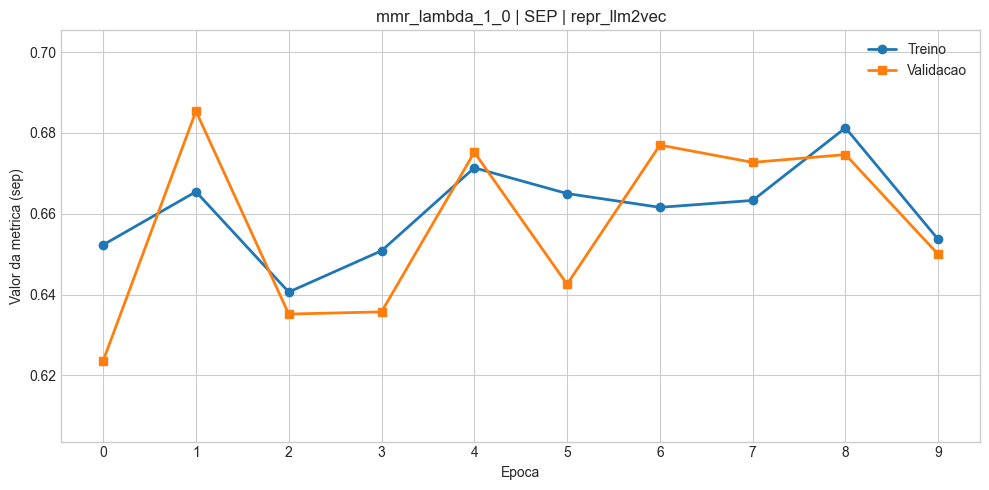

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 9 com valor 0.6689
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6350
- Delta vs without_optimization: +0.0075
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 215.89s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.661578,0.010743,0.655920,0.020208,sim,sim,293,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 3 (0..."
5,5,0.667857,0.006278,0.648433,-0.007487,sim,sim,304,"epoca 1 (0.6655), epoca 4 (0.6616), epoca 3 (0..."
6,6,0.660109,-0.007748,0.638376,-0.010057,sim,sim,294,"epoca 5 (0.6679), epoca 1 (0.6655), epoca 3 (0..."
7,7,0.662723,0.002614,0.645695,0.007319,sim,sim,546,"epoca 5 (0.6679), epoca 1 (0.6655), epoca 6 (0..."
8,8,0.641658,-0.021065,0.641329,-0.004367,sim,sim,432,"epoca 5 (0.6679), epoca 1 (0.6655), epoca 7 (0..."
9,9,0.668865,0.027206,0.661567,0.020238,sim,sim,477,"epoca 5 (0.6679), epoca 1 (0.6655), epoca 7 (0..."


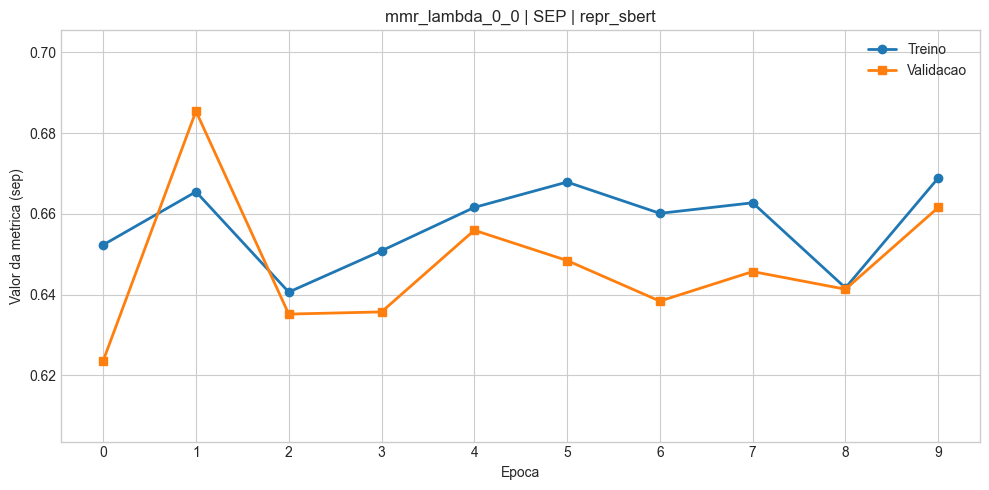

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 6 com valor 0.6669
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6254
- Delta vs without_optimization: -0.0021
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 211.51s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.661578,0.010743,0.655920,0.020208,sim,sim,293,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 3 (0..."
5,5,0.647271,-0.014307,0.659698,0.003778,sim,sim,359,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 3 (0..."
6,6,0.666892,0.019621,0.659758,0.000060,sim,sim,182,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 3 (0..."
7,7,0.646814,-0.020078,0.671574,0.011816,sim,sim,345,"epoca 6 (0.6669), epoca 3 (0.6508), epoca 5 (0..."
8,8,0.656503,0.009689,0.651888,-0.019686,sim,sim,449,"epoca 6 (0.6669), epoca 1 (0.6655), epoca 7 (0..."
9,9,0.666262,0.009759,0.655750,0.003862,sim,sim,338,"epoca 6 (0.6669), epoca 1 (0.6655), epoca 7 (0..."


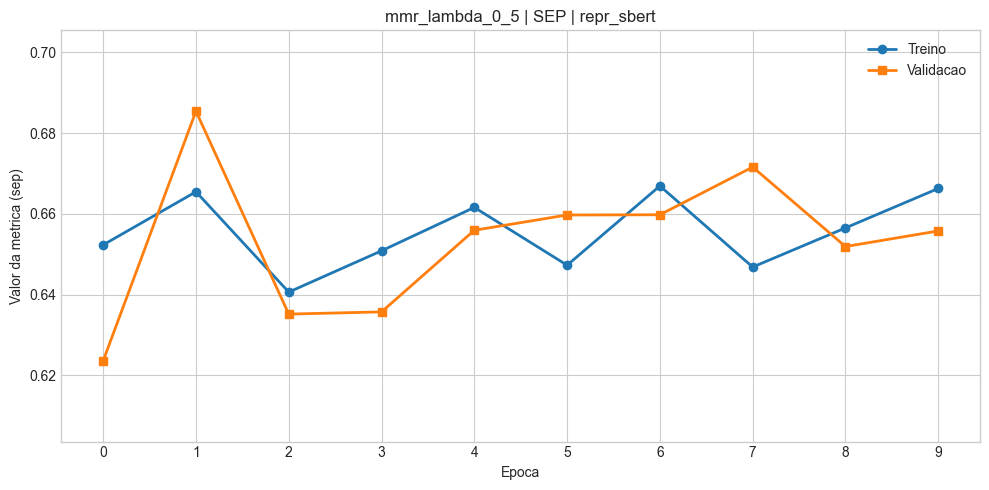

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 4 com valor 0.6737
- Melhor validacao: epoca 1 com valor 0.6854
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6434
- Delta vs without_optimization: +0.0159
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 214.88s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do texto bruto em `prompt_this_epoch`, contando letras, espacos, pontuacao e quebras de linha.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.652300,NaN,0.623603,NaN,nao,nao,317,sem refs MMR
1,1,0.665453,0.013153,0.685398,0.061795,sim,sim,271,epoca 0 (0.6523)
2,2,0.640613,-0.024841,0.635168,-0.050231,sim,sim,381,"epoca 1 (0.6655), epoca 0 (0.6523)"
3,3,0.650835,0.010222,0.635712,0.000544,sim,sim,288,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
4,4,0.673748,0.022914,0.665467,0.029755,sim,sim,261,"epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0..."
5,5,0.658480,-0.015269,0.633353,-0.032114,sim,sim,277,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 0 (0..."
6,6,0.646781,-0.011699,0.646081,0.012728,sim,sim,341,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 0 (0..."
7,7,0.665001,0.018220,0.649665,0.003584,sim,sim,277,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 0 (0..."
8,8,0.666853,0.001852,0.644334,-0.005331,sim,sim,281,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 0 (0..."
9,9,0.655681,-0.011171,0.672469,0.028135,sim,sim,275,"epoca 4 (0.6737), epoca 1 (0.6655), epoca 0 (0..."


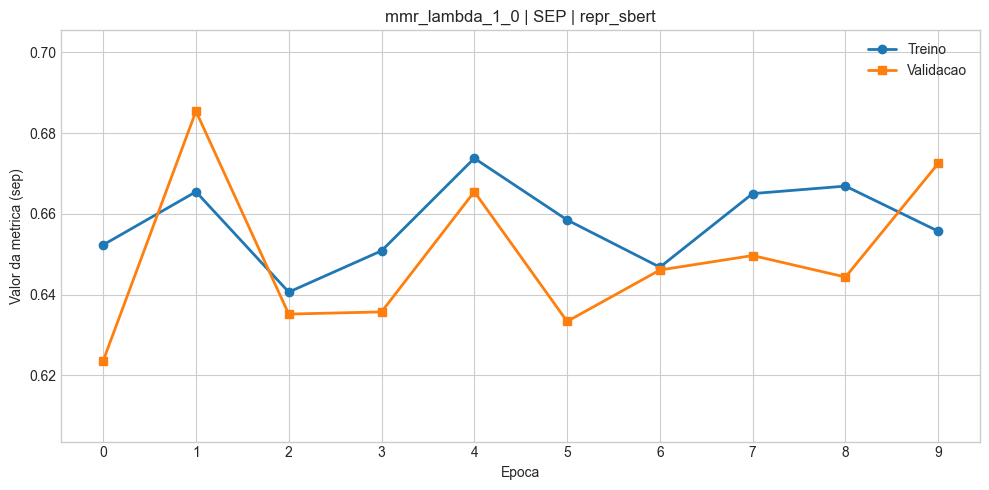

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6523 (sem anterior)
- Validacao: 0.6236 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 317 caracteres

Prompt completo:
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6655 (+0.0132)
- Validacao: 0.6854 (+0.0618)
- Refs MMR: epoca 0 (0.6523)
- Tamanho do prompt: 271 caracteres

Prompt completo:
```text
To refine your recommendation,
- Highlight unique attributes that set the recommended item apart.
- Leverage detailed information over vague descriptions whenever possible.
- When several options match, select the path where interactions between items are best justified.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6406 (-0.0248)
- Validacao: 0.6352 (-0.0502)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523)
- Tamanho do prompt: 381 caracteres

Prompt completo:
```text
Recommendation Guidance:

When evaluating different pathways, prioritize attributes that accurately distinguish and describe key relationships between the involved items. 
Limit reliance on excessively general terms unless unavoidable. In such cases, favor explanations connecting the interacted and recommended items directly, offering clearer justifications for their connection.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6508 (+0.0102)
- Validacao: 0.6357 (+0.0005)
- Refs MMR: epoca 1 (0.6655), epoca 0 (0.6523), epoca 2 (0.6406)
- Tamanho do prompt: 288 caracteres

Prompt completo:
```text
Recommendation Insights:

Prioritize pathways based on precise connections
– Restrict consideration to descriptive attributes that distinctly characterise involved items and links between them
– Where ambiguity remains, consider direct, well-defined correlations as primary justification.
```

...

### repr_llm2vec | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 8
- Ganho da melhor epoca vs base no treino: +0.0290 (0.6523 -> 0.6813)
- Ganho da melhor epoca vs base na validacao: +0.0510 (0.6236 -> 0.6746)
- Teste sem otimizacao vs com melhor prompt: 0.6275 -> 0.6382 (+0.0107)
- Prompt base (epoca 0):
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```
- Melhor prompt:
```text
Strategic Evaluation Protocol
 
Closely examine explanation paths centered around highly discriminative attributes that distinctly separate interacted and recommended items across multiple viewpoints whenever feasible.
  
Prioritize pathways featuring granular information rich segments that conclusively distinguish items by their key differentiating characteristics whenever they exist.
```

### repr_sbert | mmr_lambda_0_0 | mmr_pool_10
- Melhor epoca: 9
- Ganho da melhor epoca vs base no treino: +0.0166 (0.6523 -> 0.6689)
- Ganho da melhor epoca vs base na validacao: +0.0380 (0.6236 -> 0.6616)
- Teste sem otimizacao vs com melhor prompt: 0.6275 -> 0.6350 (+0.0075)
- Prompt base (epoca 0):
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```
- Melhor prompt:
```text
Precision Explanation Selection

Prioritize clear explanations backed by concrete attributes connecting interacted and recommended items. 
When multiple options exist, opt for the pathway that offers the most distinct insights and justification through its chosen attribute and supporting rationale. In cases of parity across different options consider how precisely they address contrasting features, behaviors, or properties before choosing the optimal explanatory framework.
```

### repr_sbert | mmr_lambda_0_5 | mmr_pool_10
- Melhor epoca: 6
- Ganho da melhor epoca vs base no treino: +0.0146 (0.6523 -> 0.6669)
- Ganho da melhor epoca vs base na validacao: +0.0362 (0.6236 -> 0.6598)
- Teste sem otimizacao vs com melhor prompt: 0.6275 -> 0.6254 (-0.0021)
- Prompt base (epoca 0):
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```
- Melhor prompt:
```text
Refinement Guidance 
- Select preferences by prioritizing pathway detail, leveraging specific attributes to define relationships between interacted and recommended items effectively.
```

### repr_sbert | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 4
- Ganho da melhor epoca vs base no treino: +0.0214 (0.6523 -> 0.6737)
- Ganho da melhor epoca vs base na validacao: +0.0419 (0.6236 -> 0.6655)
- Teste sem otimizacao vs com melhor prompt: 0.6275 -> 0.6434 (+0.0159)
- Prompt base (epoca 0):
```text
Selection guidance:
- Prefer attributes that provide more informative, specific, and discriminative explanations.
- Avoid attributes that are overly broad or apply to many items when a more specific attribute exists.
- Prefer attributes that better explain why the recommended item is related to the interacted item.

```
- Melhor prompt:
```text
Refine Your Recommendation

- Attribute preference should ascend towards specificity and distinctness while ensuring inter-item correlations remain discernible.
- Limit usage of superfluous descriptor phrases unless they establish direct linkages between items.
```

### Comparacao final de teste
- Sem otimizacao: 0.6275 em SEP
- Tempo sem otimizacao: 215.43s
- Prompt sem otimizacao:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.

```
- Melhor resultado com otimizacao: 0.6434 em SEP
- Melhor configuracao no teste: mmr_lambda_0_5 | repr_llm2vec
- Tempo da melhor configuracao: 213.73s
- Ganho vs sem otimizacao: +0.0159
- Prompt da melhor configuracao no teste:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.

```

In [5]:
final_reports = []

if DEFAULT_TEST_RESULT is not None:
    display(Markdown(build_default_test_markdown(DEFAULT_TEST_RESULT)))

if catalog.empty:
    print(f"Nenhum arquivo optimization_process_metadata.json do ncf foi encontrado em {DATA_DIR}.")
else:
    for metadata_path in catalog["optimization_metadata_path"]:
        print(f"Plotando rodada do ncf: {metadata_path.relative_to(PROJECT_ROOT)}")
        plot_history(Path(metadata_path), save_figures=SAVE_FIGURES)

        payload, history, metric_name, lambda_name, pool_name = load_history(Path(metadata_path))
        history_table = build_history_table(history, metric_name, lambda_name, pool_name)
        test_result = find_test_result_for_metadata(Path(metadata_path), payload)
        final_reports.append(
            build_final_report_markdown(
                Path(metadata_path),
                payload,
                history_table,
                test_result,
                DEFAULT_TEST_RESULT,
            )
        )

    display(Markdown("## Relatório Final"))
    for report in final_reports:
        display(Markdown(report))
    display(Markdown(build_best_test_summary_markdown(DEFAULT_TEST_RESULT, with_opt_test_catalog)))

    if SAVE_FIGURES:
        print(f"Figuras do ncf salvas em: {FIGURES_DIR}")
